In [1]:
import sys
import os
from pathlib import Path

if 'google.colab' in sys.modules:
    !pip install -U ipython
    !git clone https://github.com/AdrianPanasiewicz/QML_for_radar_classification.git
    repo_path = '/content/QML_for_radar_classification'
    if repo_path not in sys.path:
        sys.path.insert(0, repo_path)

    colab_run_dir = os.path.join(repo_path, 'colab_run')
    os.makedirs(colab_run_dir, exist_ok=True)
    os.chdir(colab_run_dir)

    !pip install -q pennylane
    !pip install "ray[tune]"


%load_ext autoreload
%autoreload 2

%aimport -torch
%aimport -numpy
%aimport -qiskit
%aimport -pennylane
%aimport -ray
%aimport -sklearn

# These import from Data folder are necessary for pickle load to work
from Data.Primitives.environment_classes import Drone, Radar, Context
from Data.Primitives.noise_models import AdditiveWhiteGaussianNoise
from Data.Primitives.presets import *
from Data.Generators.synthetic_dataset_generator import DatasetMetadata, DataRequest

from MachineLearning.Processing.file_loader import SyntheticDataFileLoader
from MachineLearning.Processing.frequency_domain_parser import FrequencyDomainDataParser
from MachineLearning.Processing.time_domain_parser import TimeDomainDataParser
from MachineLearning.Torch_datasets.synthetic_time_dataset import SyntheticTimeDomainRadarDataset
from MachineLearning.Torch_datasets.synthetic_frequency_dataset import SyntheticFrequencyDomainRadarDataset
from MachineLearning.Models.experiment_pure.classical_neural_network import ClassicalNeuralNetwork
from MachineLearning.Models.experiment_pure.quantum_neural_network import QuantumNeuralNetwork
from MachineLearning.Processing.data_visualizer import DataVisualizer
from MachineLearning.Trainers.statistical_trainer import TrainerForModelStatistics
from MachineLearning.Trainers.hyperparameter_trainer import TrainerForHyperparameterSearch

from matplotlib import pyplot as plt
import numpy as np

from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import sympy

import torch
from torch import nn
from torch.nn.functional import normalize
from torch.utils.data import DataLoader
from torch.optim import SGD

import ray
from ray import tune
from ray.tune import Checkpoint
from ray.tune.schedulers import ASHAScheduler

MODEL_REGISTRY = {
    "ClassicalNeuralNetwork": ClassicalNeuralNetwork,
}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.7/625.7 kB 16.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 8.5 MB/s eta 0:00:00
  Attempting uninstall: traitlets
    Found existing installation: traitlets 5.7.1
    Uninstalling traitlets-5.7.1:
      Successfully uninstalled traitlets-5.7.1
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.12.0 which is incompatible.
m

Cloning into 'QML_for_radar_classification'...
remote: Enumerating objects: 201, done.
remote: Counting objects: 100% (201/201), done.
remote: Compressing objects: 100% (140/140), done.
remote: Total 201 (delta 91), reused 159 (delta 52), pack-reused 0 (from 0)
Receiving objects: 100% (201/201), 28.79 MiB | 27.17 MiB/s, done.
Resolving deltas: 100% (91/91), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 74.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 94.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 5.0 MB/

### Checking preprocessing functionalities

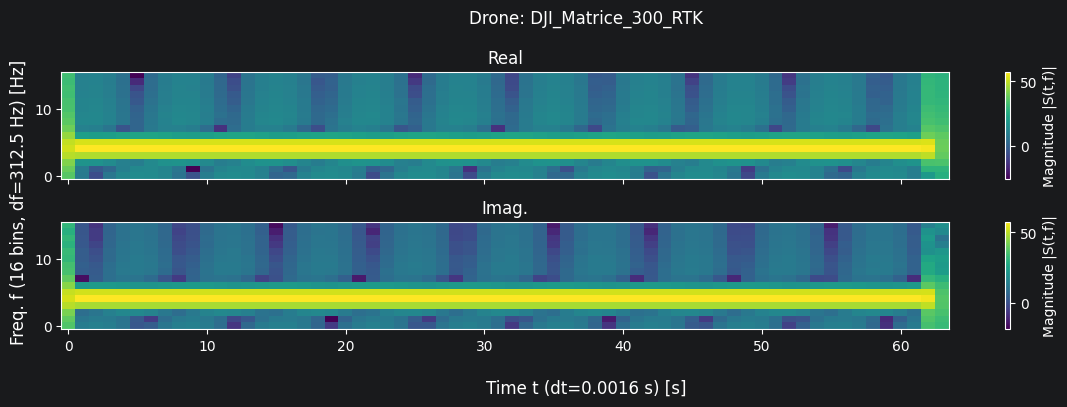

In [9]:
PROJECT_ROOT = Path().cwd().parent
type = "time_domain"
load_path = PROJECT_ROOT / "Data" / "Datasets" / type / "training_dataset.pkl"

md = DatasetMetadata.create_from_path(load_path)
synt_dataset = SyntheticDataFileLoader(dataset_metadata=md)

obj = synt_dataset.peek_sample(index=6000)

td_data_parser = TimeDomainDataParser()
signal, label, misc_data = td_data_parser.extract_training_data_and_label(obj)
td_data_parser.plot_drone_spectrogram(signal, misc_data, nperseg=32, noverlap=16)

In [10]:
parsed_signal, label, misc_data = td_data_parser.parse_data_object(obj)
parsed_signal, label, misc_data

(tensor([ 7.0232,  3.6288,  2.5064,  2.2650,  1.9713,  2.2520,  2.4046,  3.3200,
          6.2894, 89.2546]),
 1,
 DataRequest(request_name='label=DJI_Matrice_300_RTK', drone=Drone(name='DJI_Matrice_300_RTK', N=2, L_1=0.05, L_2=0.2665, f_rot=70), radar=Radar(λ=0.02998, f_c=9999748432.288193), context=Context(R=1520.0568606927932, V_rad=29.999718426099054, θ=0.3926806281264518, Φ_p=0.6228512920884408, A_r=7.299403777764336, snr=np.int64(25), t_start=0, t_stop=0.1, dt=0.0001), noise_model=<Data.noise_models.AdditiveWhiteGaussianNoise object at 0x000001B200591040>, sample_size=70))

In [11]:
PROJECT_ROOT = Path().cwd().parent
type = "frequency_domain"
load_path = PROJECT_ROOT / "Data" / "Datasets" / type / "training_dataset.pkl"

md = DatasetMetadata.create_from_path(load_path)
synt_dataset = SyntheticDataFileLoader(dataset_metadata=md)

obj = synt_dataset.peek_sample(index=6000)

td_data_parser = FrequencyDomainDataParser()
signal, label, misc_data = td_data_parser.parse_data_object(obj, bin_size=1, return_mag=False)
print(signal.shape)

torch.Size([2, 16, 64])


### Hyperparameter learner

In [2]:
# Safely import the colab module
try:
    from google.colab import output
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = Path().cwd().parent
ray.shutdown()

ctx = ray.init(
    _metrics_export_port=8080,
    runtime_env={
        "working_dir": str(PROJECT_ROOT),
        "excludes": [
            "Data/Datasets"
        ]
    }
)

if IN_COLAB:
    print("Loading Ray Dashboard:")
    output.serve_kernel_port_as_iframe(8265, height=600)

    print("Loading Ray Metrics Export:")
    output.serve_kernel_port_as_iframe(8080, height=400)
else:
    print(f"Running locally. Dashboard available at: {ctx.dashboard_url}")
    print("Metrics available at: http://127.0.0.1:8080")

2026-04-21 09:01:35,231	INFO worker.py:2012 -- Started a local Ray instance.
2026-04-21 09:01:35,236	WARNING working_dir.py:86 -- Directory '.git' is now ignored by default when packaging the working directory. To disable this behavior, set the `RAY_OVERRIDE_RUNTIME_ENV_DEFAULT_EXCLUDES=''` environment variable.
2026-04-21 09:01:35,250	INFO packaging.py:392 -- Ignoring upload to cluster for these files: [PosixPath('/content/QML_for_radar_classification/.idea/.gitignore')]
2026-04-21 09:01:35,256	INFO packaging.py:691 -- Creating a file package for local module '/content/QML_for_radar_classification'.
2026-04-21 09:01:35,269	INFO packaging.py:392 -- Ignoring upload to cluster for these files: [PosixPath('/content/QML_for_radar_classification/.idea/.gitignore')]
2026-04-21 09:01:35,275	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_cab8f03061e71a79.zip' (0.79MiB) to Ray cluster...
2026-04-21 09:01:35,280	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray

Loading Ray Dashboard:


/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


<IPython.core.display.Javascript object>

Loading Ray Metrics Export:


<IPython.core.display.Javascript object>

In [3]:
config_params = 128
divs_array = sympy.divisors(config_params)

pair_map = {div : config_params // div for div in divs_array}

config = {
    "layers": tune.grid_search(list(pair_map.keys())),
    "neurons_per_layer": tune.sample_from(lambda config: pair_map[config["layers"]]),
    "lr": tune.loguniform(1e-6, 1e-1),
    "batch_size": tune.choice([2, 4, 8, 16]),
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    'epochs' : 250
}


max_num_epochs = 500
num_trials =  100
scheduler = ASHAScheduler(
    max_t=max_num_epochs,
    grace_period=1,
    reduction_factor=2,
)

cpus_per_trial = 2
gpus_per_trial = 1

PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"
testing_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "testing_dataset.pkl"

trainer = TrainerForHyperparameterSearch(
    training_path=training_path,
    validating_path=validating_path,
    testing_path=testing_path,
    criterion = nn.CrossEntropyLoss()
)

tuner = tune.Tuner(
    tune.with_resources(
        tune.with_parameters(trainer.train_model, model_class=ClassicalNeuralNetwork),
        resources={"cpu": cpus_per_trial, "gpu": gpus_per_trial}
    ),
    tune_config=tune.TuneConfig(
        metric="loss",
        mode="min",
        scheduler=scheduler,
        num_samples=num_trials,
        trial_dirname_creator=lambda trial: f"t_{trial.trial_id}"
    ),
    param_space=config,
)
results = tuner.fit()

+--------------------------------------------------------------------+
| Configuration for experiment     train_model_2026-04-21_09-01-41   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        AsyncHyperBandScheduler           |
| Number of trials                 800                               |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/train_model_2026-04-21_09-01-41
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-04-21_09-01-25_756395_790/artifacts/2026-04-21_09-01-41/train_model_2026-04-21_09-01-41/driver_artifacts`

Trial status: 200 PENDING
Current time: 2026-04-21 09:02:41. Total running time: 59s
Logical resource usage: 2.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
+-------------------------------------------------------------

(train_model pid=1684) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00000/checkpoint_000000)
(train_model pid=1684) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00000/checkpoint_000001)
(train_model pid=1684) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00000/checkpoint_000002)
(train_model pid=1684) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00000/checkpoint_000003)
(train_model pid=1684) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00000/checkpoint_000004)
(train_model pid=1684) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_mod


Trial status: 1 RUNNING | 200 PENDING
Current time: 2026-04-21 09:03:11. Total running time: 1min 29s
Logical resource usage: 2.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
Current best trial: b690f_00000 with loss=0.693011462688446 and params={'layers': 1, 'neurons_per_layer': 128, 'lr': 1.2427222509209081e-05, 'batch_size': 8, 'device': 'cuda', 'epochs': 250}
+--------------------------------------------------------------------------------------------------------------------------------+
| Trial name                status              lr     batch_size     layers     iter     total time (s)       loss     accuracy |
+--------------------------------------------------------------------------------------------------------------------------------+
| train_model_b690f_00000   RUNNING    1.24272e-05              8          1       69            18.4211   0.693011     0.517857 |
| train_model_b690f_00001   PENDING    0.00743443               8          2                             

(train_model pid=1684) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00000/checkpoint_000068)
(train_model pid=1684) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00000/checkpoint_000069)
(train_model pid=1684) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00000/checkpoint_000070)
(train_model pid=1684) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00000/checkpoint_000071)
(train_model pid=1684) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00000/checkpoint_000072)
(train_model pid=1684) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_mod

Trial status: 1 RUNNING | 200 PENDING
Current time: 2026-04-21 09:03:41. Total running time: 1min 59s
Logical resource usage: 2.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
Current best trial: b690f_00000 with loss=0.6926648020744324 and params={'layers': 1, 'neurons_per_layer': 128, 'lr': 1.2427222509209081e-05, 'batch_size': 8, 'device': 'cuda', 'epochs': 250}
+--------------------------------------------------------------------------------------------------------------------------------+
| Trial name                status              lr     batch_size     layers     iter     total time (s)       loss     accuracy |
+--------------------------------------------------------------------------------------------------------------------------------+
| train_model_b690f_00000   RUNNING    1.24272e-05              8          1      205            47.0429   0.692665     0.510714 |
| train_model_b690f_00001   PENDING    0.00743443               8          2                             

...

(train_model pid=4218) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00022/checkpoint_000025)
(train_model pid=4218) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00022/checkpoint_000026)
(train_model pid=4218) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00022/checkpoint_000027)
(train_model pid=4218) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00022/checkpoint_000028)
(train_model pid=4218) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00022/checkpoint_000029)
(train_model pid=4218) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_mod

Trial status: 22 TERMINATED | 1 RUNNING | 200 PENDING
Current time: 2026-04-21 09:10:12. Total running time: 8min 30s
Logical resource usage: 2.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
Current best trial: b690f_00000 with loss=0.6925670504570007 and params={'layers': 1, 'neurons_per_layer': 128, 'lr': 1.2427222509209081e-05, 'batch_size': 8, 'device': 'cuda', 'epochs': 250}
+----------------------------------------------------------------------------------------------------------------------------------+
| Trial name                status                lr     batch_size     layers     iter     total time (s)       loss     accuracy |
+----------------------------------------------------------------------------------------------------------------------------------+
| train_model_b690f_00022   RUNNING      0.000409303              8         64       43           76.9256    0.693147     0.5      |
| train_model_b690f_00000   TERMINATED   1.24272e-05              8          1   

(train_model pid=4218) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00022/checkpoint_000043)
(train_model pid=4218) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00022/checkpoint_000044)
(train_model pid=4218) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00022/checkpoint_000045)
(train_model pid=4218) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00022/checkpoint_000046)
(train_model pid=4218) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00022/checkpoint_000047)
(train_model pid=4218) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_mod

Trial status: 22 TERMINATED | 1 RUNNING | 200 PENDING
Current time: 2026-04-21 09:10:29. Total running time: 8min 47s
Logical resource usage: 2.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
Current best trial: b690f_00000 with loss=0.6925670504570007 and params={'layers': 1, 'neurons_per_layer': 128, 'lr': 1.2427222509209081e-05, 'batch_size': 8, 'device': 'cuda', 'epochs': 250}
+----------------------------------------------------------------------------------------------------------------------------------+
| Trial name                status                lr     batch_size     layers     iter     total time (s)       loss     accuracy |
+----------------------------------------------------------------------------------------------------------------------------------+
| train_model_b690f_00022   RUNNING      0.000409303              8         64       52           92.5023    0.693148     0.5      |
| train_model_b690f_00000   TERMINATED   1.24272e-05              8          1   

2026-04-21 09:10:30,287	WARNING tune.py:1048 -- Experiment has been interrupted, but the most recent state was saved.
Resume experiment with: Tuner.restore(path="/root/ray_results/train_model_2026-04-21_09-01-41", trainable=...)
(train_model pid=4218) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00022/checkpoint_000052)
2026-04-21 09:10:30,423	WARNING experiment_analysis.py:180 -- Failed to fetch metrics for 200 trial(s):
- train_model_b690f_00023: FileNotFoundError('Could not fetch metrics for train_model_b690f_00023: both result.json and progress.csv were not found at /root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00023')
- train_model_b690f_00024: FileNotFoundError('Could not fetch metrics for train_model_b690f_00024: both result.json and progress.csv were not found at /root/ray_results/train_model_2026-04-21_09-01-41/t_b690f_00024')
- train_model_b690f_00025: FileNotFoundError('Could not f

### Statistical learner

In [2]:
def l1_normalize_1d(x):
    return normalize(x, p=1, dim=0)

def l2_normalize_1d(x):
    return normalize(x, dim=0)

In [ ]:
PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"
testing_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "testing_dataset.pkl"


config = {
    "layers": 2,
    "neurons_per_layer": 250,
    "lr": 1e-3,
    "batch_size": 16,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    'epochs' : 100
}

trainer = TrainerForModelStatistics(training_path, validating_path, testing_path, criterion = nn.CrossEntropyLoss())
data_array_all_runs = trainer.train_model(ClassicalNeuralNetwork, config, number_of_trials=10, number_of_epochs=500)

Model runs:  20%|██        | 2/10 [01:53<07:32, 56.51s/it]

In [ ]:
data_array = torch.tensor(
    [data_array_all_runs[i]['accuracy'] for i in range(len(data_array_all_runs))],
    dtype=torch.float32
)

plotter = DataVisualizer()
means, stds = plotter.calculate_statistics(data_array)
plotter.plot_statistics(means, stds)

### Quantum Neural Network

In [13]:
batch_size = 64
num_qubits = 10

PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"

training_data = SyntheticTimeDomainRadarDataset(training_path)
validating_data = SyntheticTimeDomainRadarDataset(validating_path, mean=training_data.mean, std=training_data.std)

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
validating_dataloader = DataLoader(validating_data, batch_size=64, shuffle=True)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
quantum_model = QuantumNeuralNetwork(num_qubits).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(quantum_model.parameters(), lr=1e-3)

trainer = TrainerForHyperparameterSearch(
    training_dataloader=train_dataloader,
    validating_dataloader=validating_dataloader,
    testing_dataloader=None,
    loss_fn=criterion,
)

epochs = 10
accuracy_array=[]
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    trainer.train()
    acc = trainer.test()
    accuracy_array.append(acc)
print("Done!")

Epoch 1
-------------------------------
loss: 1.802852  [   64/ 4620]
Test Error: 
 Accuracy: 15.5%, Avg loss: 1.795701 

Epoch 2
-------------------------------
loss: 1.784019  [   64/ 4620]
Test Error: 
 Accuracy: 15.5%, Avg loss: 1.795918 

Epoch 3
-------------------------------
loss: 1.789067  [   64/ 4620]
Test Error: 
 Accuracy: 15.5%, Avg loss: 1.795346 

Epoch 4
-------------------------------
loss: 1.792531  [   64/ 4620]
Test Error: 
 Accuracy: 15.5%, Avg loss: 1.795292 

Epoch 5
-------------------------------
loss: 1.789393  [   64/ 4620]


KeyboardInterrupt: 